# USAD Transfer Learning — Sensor 68 Temperatura SIATA (Plan K v2)

**Objetivo:** Detectar anomalías de temperatura en el sensor SIATA #68 (Jardin Botanico, Medellín)  
usando Transfer Learning desde el modelo USAD preentrenado en SWaT (51 sensores).

**Cambios respecto a Plan K:**
- `alpha=0.1, beta=0.9` — más peso al componente adversarial AE2 para mejorar discriminación
- `epochs_p1=20` — reduce sobrereconstrucción (val_loss1→0 bloqueaba la señal)
- Corrección automática de score invertido: si AUC < 0.5 → `score = max_score − score`
- Gráficas de error de reconstrucción (Val/Test) → **Plotly interactivo** con rangeslider y hover
- Curva de entrenamiento → **Plotly interactivo**
- Histograma distribución de scores Normal vs Anomalía (**nueva celda 12b**)
- Umbral dual: Balanced Accuracy + F1-óptimo
- Checkpoint guarda `score_inverted`, `threshold_f1`, `alpha`, `beta`


In [1]:
# Celda 1 — Setup Colab: clonar repo y configurar sys.path
import os, sys

REPO_URL = "https://github.com/ronvas234/data-science-monograph.git"
REPO_DIR = "data-science-monograph"
BRANCH   = 'feature/transfer-learning-plan-k'

# Instalar git-lfs para poder descargar el CSV grande
os.system('apt-get install -y git-lfs 2>/dev/null')

if not os.path.exists(REPO_DIR):
    os.system(f'git clone -b {BRANCH} {REPO_URL}')

if os.path.basename(os.getcwd()) != REPO_DIR:
    os.chdir(REPO_DIR)

# Descargar objetos LFS (CSV de temperatura)
os.system('git lfs pull')

USAD_MODULE_PATH = os.path.abspath("modelos/usad")
if USAD_MODULE_PATH not in sys.path:
    sys.path.insert(0, USAD_MODULE_PATH)

print(f"CWD: {os.getcwd()}")
print(f"USAD path en sys.path: {USAD_MODULE_PATH}")
print(f"Archivos USAD: {os.listdir(USAD_MODULE_PATH)}")

CWD: /content/data-science-monograph
USAD path en sys.path: /content/data-science-monograph/modelos/usad
Archivos USAD: ['Monografia_USAD_TL_Sensor68_PlanK.ipynb', 'LICENSE', 'utils.py', 'README.md', 'gdrivedl.py', 'data', 'USAD.ipynb', 'usad.py', 'model.pth']


In [2]:
# Celda 2 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from dataclasses import dataclass
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    balanced_accuracy_score,
    precision_score, recall_score,
    f1_score, accuracy_score,
    confusion_matrix as sk_confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import plotly.graph_objects as go
from plotly.subplots import make_subplots

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
torch.manual_seed(42)
np.random.seed(42)


Device: cpu


In [3]:
# Celda 3 — Clases del modelo (arquitectura submatrix-compatible)
#
# EncoderNew mantiene las dimensiones internas del pretrained (h1=306, h2=153, z_size=120)
# pero acepta input de 1 sensor: in_size = window_size = 12

class EncoderNew(nn.Module):
    def __init__(self, in_size=12, h1=306, h2=153, z_size=120):
        super().__init__()
        self.linear1 = nn.Linear(in_size, h1)
        self.linear2 = nn.Linear(h1, h2)
        self.linear3 = nn.Linear(h2, z_size)
        self.relu = nn.ReLU(True)

    def forward(self, w):
        out = self.relu(self.linear1(w))
        out = self.relu(self.linear2(out))
        z   = self.relu(self.linear3(out))
        return z


class DecoderNew(nn.Module):
    """Decoder con Sigmoid (compatible con MinMaxScaler [0,1])."""
    def __init__(self, z_size=120, h1=153, h2=306, out_size=12):
        super().__init__()
        self.linear1 = nn.Linear(z_size, h1)
        self.linear2 = nn.Linear(h1, h2)
        self.linear3 = nn.Linear(h2, out_size)
        self.relu    = nn.ReLU(True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, z):
        out = self.relu(self.linear1(z))
        out = self.relu(self.linear2(out))
        w   = self.sigmoid(self.linear3(out))
        return w


class UsadModelNew(nn.Module):
    def __init__(self, w_size=12, z_size=120, h1=306, h2=153):
        super().__init__()
        self.encoder  = EncoderNew(w_size, h1, h2, z_size)
        self.decoder1 = DecoderNew(z_size, h2, h1, w_size)
        self.decoder2 = DecoderNew(z_size, h2, h1, w_size)

    def training_step(self, batch, n):
        z  = self.encoder(batch)
        w1 = self.decoder1(z)
        w2 = self.decoder2(z)
        w3 = self.decoder2(self.encoder(w1))
        loss1 = 1/n * torch.mean((batch-w1)**2) + (1-1/n) * torch.mean((batch-w3)**2)
        loss2 = 1/n * torch.mean((batch-w2)**2) - (1-1/n) * torch.mean((batch-w3)**2)
        return loss1, loss2

    def validation_step(self, batch, n):
        with torch.no_grad():
            z  = self.encoder(batch)
            w1 = self.decoder1(z)
            w2 = self.decoder2(z)
            w3 = self.decoder2(self.encoder(w1))
            loss1 = 1/n * torch.mean((batch-w1)**2) + (1-1/n) * torch.mean((batch-w3)**2)
            loss2 = 1/n * torch.mean((batch-w2)**2) - (1-1/n) * torch.mean((batch-w3)**2)
        return {'val_loss1': loss1.item(), 'val_loss2': loss2.item()}

print("Clases de modelo definidas: EncoderNew, DecoderNew, UsadModelNew")

Clases de modelo definidas: EncoderNew, DecoderNew, UsadModelNew


In [4]:
# Celda 4 — WeightTransferService: extracción de submatriz norm-ranked

class WeightTransferService:
    """
    Extrae una submatriz del modelo USAD pretrained (51 sensores, w=612)
    para inicializar un modelo de 1 sensor (w=12).
    Estrategia: seleccionar las w_size_new columnas de mayor norma L2
    en la primera capa del encoder (más representativas del espacio latente).
    """

    @staticmethod
    def load_pretrained_state(model_path):
        """Carga el checkpoint y devuelve state_dicts del encoder y decoder1."""
        checkpoint = torch.load(model_path, map_location='cpu')

        # Soporte para distintos formatos de guardado
        if isinstance(checkpoint, dict):
            if 'encoder' in checkpoint and isinstance(checkpoint['encoder'], dict):
                # Formato: {'encoder': state_dict, 'decoder1': state_dict, ...}
                enc_sd = checkpoint['encoder']
                dec_sd = checkpoint['decoder1']
            else:
                # Formato: state_dict completo con prefijos
                enc_sd = {k.replace('encoder.', ''): v
                          for k, v in checkpoint.items() if k.startswith('encoder.')}
                dec_sd = {k.replace('decoder1.', ''): v
                          for k, v in checkpoint.items() if k.startswith('decoder1.')}
        else:
            raise ValueError(f"Formato de checkpoint no reconocido: {type(checkpoint)}")

        return enc_sd, dec_sd

    @staticmethod
    def extract_submatrix(model_path, w_size_new=12):
        """
        Selecciona w_size_new columnas de mayor norma L2 de linear1.weight
        del encoder (shape: [306, 612]) → [306, w_size_new].
        Las mismas filas se extraen de linear3.weight del decoder (shape: [612, 306]).
        """
        enc_sd, dec_sd = WeightTransferService.load_pretrained_state(model_path)

        W1_orig = enc_sd['linear1.weight']  # (306, 612)
        print(f"Encoder linear1 original: {W1_orig.shape}")

        # Norm-ranked: top columnas por norma L2
        col_norms = W1_orig.norm(dim=0)                 # (612,)
        top_cols  = col_norms.topk(w_size_new).indices  # (w_size_new,)
        top_cols_sorted = top_cols.sort().values
        print(f"Top {w_size_new} columnas (índices): {top_cols_sorted.tolist()}")
        print(f"Normas: min={col_norms[top_cols_sorted].min():.4f}  "
              f"max={col_norms[top_cols_sorted].max():.4f}")

        W3_dec_orig = dec_sd['linear3.weight']  # (612, 306)

        new_weights = {
            'encoder': {
                'linear1.weight': W1_orig[:, top_cols_sorted].clone(),   # (306, 12)
                'linear1.bias':   enc_sd['linear1.bias'].clone(),         # (306,)
                'linear2.weight': enc_sd['linear2.weight'].clone(),       # (153, 306)
                'linear2.bias':   enc_sd['linear2.bias'].clone(),         # (153,)
                'linear3.weight': enc_sd['linear3.weight'].clone(),       # (120, 153)
                'linear3.bias':   enc_sd['linear3.bias'].clone(),         # (120,)
            },
            'decoder': {
                'linear1.weight': dec_sd['linear1.weight'].clone(),       # (153, 120)
                'linear1.bias':   dec_sd['linear1.bias'].clone(),         # (153,)
                'linear2.weight': dec_sd['linear2.weight'].clone(),       # (306, 153)
                'linear2.bias':   dec_sd['linear2.bias'].clone(),         # (306,)
                'linear3.weight': W3_dec_orig[top_cols_sorted, :].clone(), # (12, 306)
                'linear3.bias':   dec_sd['linear3.bias'][top_cols_sorted].clone(),  # (12,)
            }
        }
        return new_weights, top_cols_sorted

    @staticmethod
    def load_into_model(model, weights):
        """Carga pesos transferidos en el modelo nuevo."""
        enc = model.encoder
        enc.linear1.weight = nn.Parameter(weights['encoder']['linear1.weight'])
        enc.linear1.bias   = nn.Parameter(weights['encoder']['linear1.bias'])
        enc.linear2.weight = nn.Parameter(weights['encoder']['linear2.weight'])
        enc.linear2.bias   = nn.Parameter(weights['encoder']['linear2.bias'])
        enc.linear3.weight = nn.Parameter(weights['encoder']['linear3.weight'])
        enc.linear3.bias   = nn.Parameter(weights['encoder']['linear3.bias'])
        for dec in [model.decoder1, model.decoder2]:
            dec.linear1.weight = nn.Parameter(weights['decoder']['linear1.weight'].clone())
            dec.linear1.bias   = nn.Parameter(weights['decoder']['linear1.bias'].clone())
            dec.linear2.weight = nn.Parameter(weights['decoder']['linear2.weight'].clone())
            dec.linear2.bias   = nn.Parameter(weights['decoder']['linear2.bias'].clone())
            dec.linear3.weight = nn.Parameter(weights['decoder']['linear3.weight'].clone())
            dec.linear3.bias   = nn.Parameter(weights['decoder']['linear3.bias'].clone())
        return model

print("WeightTransferService definido")

WeightTransferService definido


In [5]:
# Celda 5 — Configuración

@dataclass
class Config:
    # Datos
    csv_path:     str   = 'modelos/usad/data/temperatura_estaciones_2020_2025.csv'
    model_path:   str   = 'modelos/usad/model.pth'
    sensor_id:    int   = 68
    fecha_inicio: str   = '2023-01-01'
    fecha_fin:    str   = '2023-06-30'
    t_clip_min:   float = 10.0
    t_clip_max:   float = 40.0
    train_end:    str   = '2023-04-30'
    val_start:    str   = '2023-05-01'
    val_end:      str   = '2023-05-31'
    test_start:   str   = '2023-06-01'
    # Arquitectura
    window_size:  int   = 12
    z_size:       int   = 120
    h1:           int   = 306
    h2:           int   = 153
    # Entrenamiento
    batch_size:   int   = 128
    epochs_p1:    int   = 20     # v2: reducido de 50 — evita sobrereconstrucción prematura
    epochs_p2:    int   = 100
    lr_p1:        float = 1e-3
    lr2_p1:       float = 3e-4
    lr_p2:        float = 1e-4
    lr2_p2:       float = 3e-5
    lr_patience:  int   = 10
    lr_factor:    float = 0.5
    es_patience:  int   = 20
    max_grad:     float = 1.0
    alpha:        float = 0.1   # v2: era 0.5 — menos peso en AE1 (reconstrucción directa)
    beta:         float = 0.9   # v2: era 0.5 — más peso en AE2 adversarial

cfg = Config()
print(cfg)


Config(csv_path='modelos/usad/data/temperatura_estaciones_2020_2025.csv', model_path='modelos/usad/model.pth', sensor_id=68, fecha_inicio='2023-01-01', fecha_fin='2023-06-30', t_clip_min=10.0, t_clip_max=40.0, train_end='2023-04-30', val_start='2023-05-01', val_end='2023-05-31', test_start='2023-06-01', window_size=12, z_size=120, h1=306, h2=153, batch_size=128, epochs_p1=50, epochs_p2=100, lr_p1=0.001, lr2_p1=0.0003, lr_p2=0.0001, lr2_p2=3e-05, lr_patience=10, lr_factor=0.5, es_patience=20, max_grad=1.0, alpha=0.5, beta=0.5)


In [6]:
# Celda 6 — Carga y preparación de datos

print("Cargando CSV (puede tardar ~30s en Colab)...")
df_raw = pd.read_csv(
    cfg.csv_path,
    parse_dates=['fecha_hora'],
    dtype={'codigo': 'int32', 't': 'float32', 'calidad': 'int32',
           'calidad_dudosa': 'bool', 'temperatura_dudosa': 'bool'}
)
print(f"CSV cargado: {len(df_raw):,} filas")

# Filtrar sensor y período
df = df_raw[
    (df_raw['codigo'] == cfg.sensor_id) &
    (df_raw['fecha_hora'] >= cfg.fecha_inicio) &
    (df_raw['fecha_hora'] <= cfg.fecha_fin + ' 23:59:59')
].copy().sort_values('fecha_hora').reset_index(drop=True)

print(f"Sensor {cfg.sensor_id} en período: {len(df):,} filas")
print(f"Rango de fechas: {df['fecha_hora'].iloc[0]} → {df['fecha_hora'].iloc[-1]}")
print(f"Temperatura raw: min={df['t'].min():.1f}°C  max={df['t'].max():.1f}°C")
print(f"Anomalías totales: {df['calidad_dudosa'].sum():,} ({df['calidad_dudosa'].mean()*100:.2f}%)")

# Clip físico: elimina valores imposibles (ej. -1000°C por error de sensor)
df['t_clip'] = df['t'].clip(cfg.t_clip_min, cfg.t_clip_max)
n_clipped = (df['t'] != df['t_clip']).sum()
print(f"\nValores clippeados ({cfg.t_clip_min}–{cfg.t_clip_max}°C): {n_clipped:,}")

# Split cronológico por mes (sin data leakage)
df_train = df[df['fecha_hora'] <= cfg.train_end + ' 23:59:59'].reset_index(drop=True)
df_val   = df[(df['fecha_hora'] >= cfg.val_start) &
              (df['fecha_hora'] <= cfg.val_end + ' 23:59:59')].reset_index(drop=True)
df_test  = df[df['fecha_hora'] >= cfg.test_start].reset_index(drop=True)

total = len(df_train) + len(df_val) + len(df_test)
print(f"\nSplit:")
print(f"  Train: {len(df_train):>8,} ({len(df_train)/total*100:.1f}%)  "
      f"anomalías: {df_train['calidad_dudosa'].sum():,} ({df_train['calidad_dudosa'].mean()*100:.1f}%)")
print(f"  Val:   {len(df_val):>8,} ({len(df_val)/total*100:.1f}%)  "
      f"anomalías: {df_val['calidad_dudosa'].sum():,} ({df_val['calidad_dudosa'].mean()*100:.1f}%)")
print(f"  Test:  {len(df_test):>8,} ({len(df_test)/total*100:.1f}%)  "
      f"anomalías: {df_test['calidad_dudosa'].sum():,} ({df_test['calidad_dudosa'].mean()*100:.1f}%)")

# MinMaxScaler ajustado SOLO sobre datos normales de train
scaler = MinMaxScaler()
normal_train_vals = df_train.loc[~df_train['calidad_dudosa'], 't_clip'].values.reshape(-1, 1)
scaler.fit(normal_train_vals)
print(f"\nMinMaxScaler ajustado sobre {len(normal_train_vals):,} muestras normales de train")
print(f"  Rango: [{scaler.data_min_[0]:.2f}°C, {scaler.data_max_[0]:.2f}°C] → [0, 1]")

# Normalizar todos los conjuntos
for df_split in [df_train, df_val, df_test]:
    df_split['t_norm'] = scaler.transform(
        df_split['t_clip'].values.reshape(-1, 1)
    ).flatten().astype(np.float32)

Cargando CSV (puede tardar ~30s en Colab)...
CSV cargado: 10,959,310 filas
Sensor 68 en período: 260,575 filas
Rango de fechas: 2023-01-01 00:00:00 → 2023-06-30 23:59:00
Temperatura raw: min=15.8°C  max=32.1°C
Anomalías totales: 7,962 (3.06%)

Valores clippeados (10.0–40.0°C): 0

Split:
  Train:  172,759 (66.3%)  anomalías: 5,236 (3.0%)
  Val:     44,616 (17.1%)  anomalías: 1,377 (3.1%)
  Test:    43,200 (16.6%)  anomalías: 1,349 (3.1%)

MinMaxScaler ajustado sobre 167,523 muestras normales de train
  Rango: [15.80°C, 31.10°C] → [0, 1]


In [7]:
# Celda 7 — Creación de ventanas deslizantes y DataLoaders

def make_windows(series, flags, window_size):
    """Ventanas de stride=1. Label=1 si CUALQUIER timestep es anomalía."""
    n   = len(series) - window_size + 1
    idx = np.arange(window_size)[None, :] + np.arange(n)[:, None]  # (n, W)
    windows = series[idx].astype(np.float32)    # (n, W)
    labels  = flags[idx].any(axis=1).astype(np.int8)  # (n,)
    return windows, labels

W_train, L_train = make_windows(
    df_train['t_norm'].values, df_train['calidad_dudosa'].values, cfg.window_size)
W_val,   L_val   = make_windows(
    df_val['t_norm'].values,   df_val['calidad_dudosa'].values,   cfg.window_size)
W_test,  L_test  = make_windows(
    df_test['t_norm'].values,  df_test['calidad_dudosa'].values,  cfg.window_size)

# Train: solo ventanas normales (sin anomalías)
normal_mask     = L_train == 0
W_train_normal  = W_train[normal_mask]

train_ds = TensorDataset(torch.from_numpy(W_train_normal))
val_ds   = TensorDataset(torch.from_numpy(W_val))
test_ds  = TensorDataset(torch.from_numpy(W_test))

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=cfg.batch_size, shuffle=False)

print(f"Ventanas (stride=1):")
print(f"  Train normal: {len(W_train_normal):,}")
print(f"  Val  (todas): {len(W_val):,}  |  anomalías: {L_val.sum():,} ({L_val.mean()*100:.1f}%)")
print(f"  Test (todas): {len(W_test):,}  |  anomalías: {L_test.sum():,} ({L_test.mean()*100:.1f}%)")

Ventanas (stride=1):
  Train normal: 165,032
  Val  (todas): 44,605  |  anomalías: 2,165 (4.9%)
  Test (todas): 43,189  |  anomalías: 1,824 (4.2%)


In [8]:
# Celda 8 — Inicializar modelo con pesos transferidos (submatrix TL)

pretrained_weights, top_cols = WeightTransferService.extract_submatrix(
    cfg.model_path, cfg.window_size
)

model = UsadModelNew(cfg.window_size, cfg.z_size, cfg.h1, cfg.h2).to(device)
model = WeightTransferService.load_into_model(model, pretrained_weights)

total_params     = sum(p.numel() for p in model.parameters())
encoder_params   = sum(p.numel() for p in model.encoder.parameters())
decoder_params   = sum(p.numel() for p in model.decoder1.parameters())

print(f"\nModelo inicializado con pesos transferidos:")
print(f"  Encoder linear1: {model.encoder.linear1.weight.shape}  (submatriz de 612→{cfg.window_size})")
print(f"  Decoder linear3: {model.decoder1.linear3.weight.shape}  (submatriz de 612→{cfg.window_size})")
print(f"  Parámetros encoder:   {encoder_params:,}")
print(f"  Parámetros decoder:   {decoder_params:,}")
print(f"  Parámetros totales:   {total_params:,}")

Encoder linear1 original: torch.Size([306, 612])
Top 12 columnas (índices): [47, 98, 149, 200, 251, 302, 353, 457, 508, 559, 608, 610]
Normas: min=1.3469  max=1.5734

Modelo inicializado con pesos transferidos:
  Encoder linear1: torch.Size([306, 12])  (submatriz de 612→12)
  Decoder linear3: torch.Size([12, 306])  (submatriz de 612→12)
  Parámetros encoder:   69,429
  Parámetros decoder:   69,321
  Parámetros totales:   208,071


In [11]:
# Celda 9 — Entrenamiento bifásico

def run_training(model, train_loader, val_loader, cfg, device):
    history = {'val_loss1': [], 'val_loss2': []}
    phase1_end_epoch = cfg.epochs_p1

    # ---- FASE 1: encoder congelado ----
    print("=" * 55)
    print(f"FASE 1: encoder congelado ({cfg.epochs_p1} épocas)")
    print("=" * 55)
    for p in model.encoder.parameters():
        p.requires_grad = False

    opt1 = torch.optim.Adam(model.decoder1.parameters(), lr=cfg.lr_p1)
    opt2 = torch.optim.Adam(model.decoder2.parameters(), lr=cfg.lr2_p1)
    sch1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt1, factor=cfg.lr_factor, patience=cfg.lr_patience)
    sch2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt2, factor=cfg.lr_factor, patience=cfg.lr_patience)

    for epoch in range(1, cfg.epochs_p1 + 1):
        model.train()
        for [batch] in train_loader:
            batch = batch.to(device)
            loss1, _ = model.training_step(batch, epoch)
            opt1.zero_grad()
            loss1.backward()
            nn.utils.clip_grad_norm_(model.decoder1.parameters(), cfg.max_grad)
            opt1.step()

            _, loss2 = model.training_step(batch, epoch)
            opt2.zero_grad()
            loss2.backward()
            nn.utils.clip_grad_norm_(model.decoder2.parameters(), cfg.max_grad)
            opt2.step()

        model.eval()
        val_outs = [model.validation_step(b.to(device), epoch) for [b] in val_loader]
        vl1 = float(np.mean([x['val_loss1'] for x in val_outs]))
        vl2 = float(np.mean([x['val_loss2'] for x in val_outs]))
        sch1.step(vl1); sch2.step(vl2)
        history['val_loss1'].append(vl1)
        history['val_loss2'].append(vl2)
        if epoch % 10 == 0:
            print(f"  Época {epoch:3d}/{cfg.epochs_p1} | "
                  f"val_loss1={vl1:.6f}  val_loss2={vl2:.6f}")

    # ---- FASE 2: fine-tuning completo ----
    print("\n" + "=" * 55)
    print(f"FASE 2: fine-tuning completo (hasta {cfg.epochs_p2} épocas, ES={cfg.es_patience})")
    print("=" * 55)
    for p in model.encoder.parameters():
        p.requires_grad = True

    params1 = list(model.encoder.parameters()) + list(model.decoder1.parameters())
    params2 = list(model.encoder.parameters()) + list(model.decoder2.parameters())
    opt1 = torch.optim.Adam(params1, lr=cfg.lr_p2)
    opt2 = torch.optim.Adam(params2, lr=cfg.lr2_p2)
    sch1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt1, factor=cfg.lr_factor, patience=cfg.lr_patience)
    sch2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt2, factor=cfg.lr_factor, patience=cfg.lr_patience)

    best_vl1 = float('inf')
    no_improve = 0
    best_state = None

    for local_ep in range(1, cfg.epochs_p2 + 1):
        global_ep = cfg.epochs_p1 + local_ep
        model.train()
        for [batch] in train_loader:
            batch = batch.to(device)
            loss1, _ = model.training_step(batch, local_ep)
            opt1.zero_grad()
            loss1.backward()
            nn.utils.clip_grad_norm_(params1, cfg.max_grad)
            opt1.step()

            _, loss2 = model.training_step(batch, local_ep)
            opt2.zero_grad()
            loss2.backward()
            nn.utils.clip_grad_norm_(params2, cfg.max_grad)
            opt2.step()

        model.eval()
        val_outs = [model.validation_step(b.to(device), local_ep) for [b] in val_loader]
        vl1 = float(np.mean([x['val_loss1'] for x in val_outs]))
        vl2 = float(np.mean([x['val_loss2'] for x in val_outs]))
        sch1.step(vl1); sch2.step(vl2)
        history['val_loss1'].append(vl1)
        history['val_loss2'].append(vl2)

        if vl1 < best_vl1:
            best_vl1 = vl1
            no_improve = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1

        if local_ep % 10 == 0:
            print(f"  Época {global_ep:3d} (F2 {local_ep:3d}) | "
                  f"val_loss1={vl1:.6f}  val_loss2={vl2:.6f}  "
                  f"ES={no_improve}/{cfg.es_patience}")

        if no_improve >= cfg.es_patience:
            print(f"\n  Early stopping en época global {global_ep} "
                  f"(mejor val_loss1={best_vl1:.6f})")
            break

    # Restaurar mejor estado
    if best_state is not None:
        model.load_state_dict(best_state)
        print("  Modelo restaurado al mejor estado.")

    history['phase1_end'] = phase1_end_epoch
    return history


history = run_training(model, train_loader, val_loader, cfg, device)
print(f"\nEntrenamiento completado. Total épocas: {len(history['val_loss1'])}")

FASE 1: encoder congelado (50 épocas)
  Época  10/50 | val_loss1=0.241304  val_loss2=-0.214483
  Época  20/50 | val_loss1=0.254700  val_loss2=-0.241293
  Época  30/50 | val_loss1=0.259168  val_loss2=-0.250230
  Época  40/50 | val_loss1=0.261402  val_loss2=-0.254699
  Época  50/50 | val_loss1=0.262742  val_loss2=-0.257380

FASE 2: fine-tuning completo (hasta 100 épocas, ES=20)
  Época  60 (F2  10) | val_loss1=0.241296  val_loss2=-0.214483  ES=9/20
  Época  70 (F2  20) | val_loss1=0.254699  val_loss2=-0.241293  ES=19/20

  Early stopping en época global 71 (mejor val_loss1=0.000031)
  Modelo restaurado al mejor estado.

Entrenamiento completado. Total épocas: 71


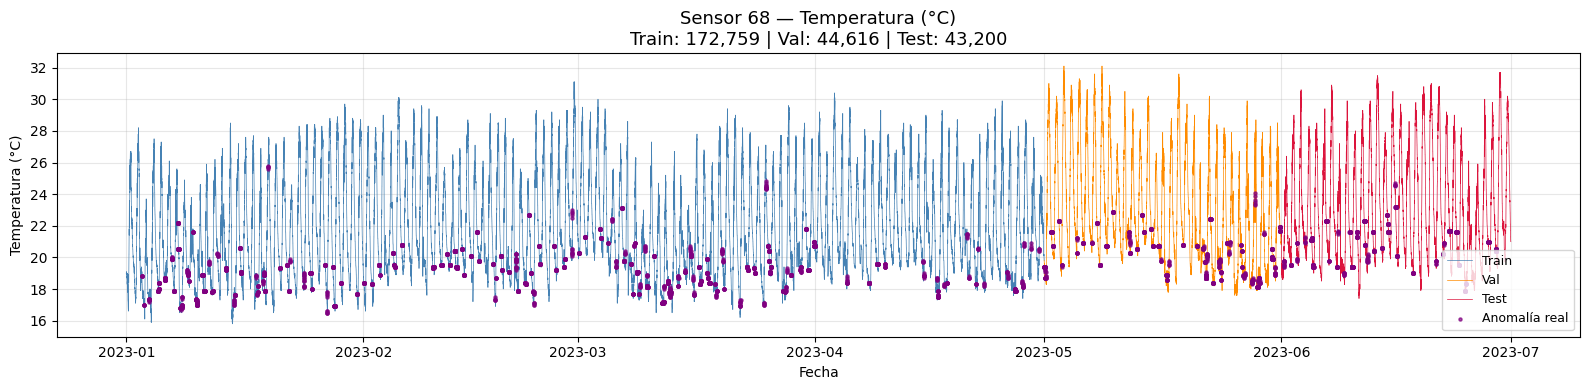

In [12]:
# Celda 10 — Gráfica 1: Serie temporal con splits y anomalías reales

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(df_train['fecha_hora'], df_train['t_clip'],
        color='steelblue', lw=0.5, label='Train')
ax.plot(df_val['fecha_hora'],   df_val['t_clip'],
        color='darkorange', lw=0.5, label='Val')
ax.plot(df_test['fecha_hora'],  df_test['t_clip'],
        color='crimson', lw=0.5, label='Test')

anom_all = df[df['calidad_dudosa']]
ax.scatter(anom_all['fecha_hora'], anom_all['t_clip'],
           color='purple', s=5, zorder=5, alpha=0.7, label='Anomalía real')

n_tr, n_va, n_te = len(df_train), len(df_val), len(df_test)
ax.set_title(
    f'Sensor {cfg.sensor_id} — Temperatura (°C)\n'
    f'Train: {n_tr:,} | Val: {n_va:,} | Test: {n_te:,}',
    fontsize=13
)
ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafica_01_splits.png', dpi=150, bbox_inches='tight')
plt.show()

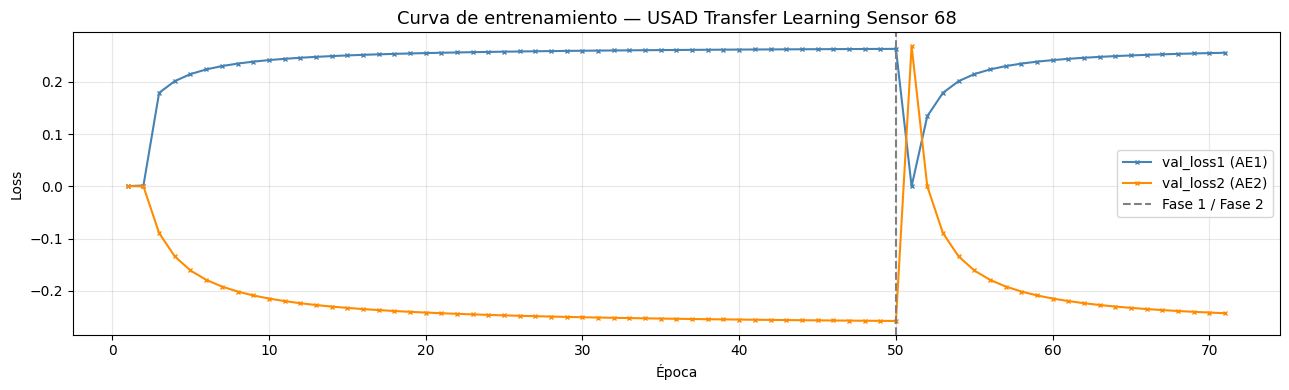

In [13]:
# Celda 11 — Gráfica 2: Curva de entrenamiento (Plotly interactivo)

epochs_all = list(range(1, len(history['val_loss1']) + 1))
p1_end     = history['phase1_end']

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=epochs_all, y=history['val_loss1'],
    mode='lines+markers',
    name='val_loss1 (AE1)',
    line=dict(color='steelblue', width=1.5),
    marker=dict(size=4, symbol='x'),
    hovertemplate='Época %{x}<br>val_loss1: %{y:.6f}<extra></extra>'
))

fig.add_trace(go.Scatter(
    x=epochs_all, y=history['val_loss2'],
    mode='lines+markers',
    name='val_loss2 (AE2)',
    line=dict(color='darkorange', width=1.5),
    marker=dict(size=4, symbol='x'),
    hovertemplate='Época %{x}<br>val_loss2: %{y:.6f}<extra></extra>'
))

fig.add_vline(
    x=p1_end,
    line_dash='dash', line_color='gray', line_width=1.5,
    annotation_text='Fase 1 / Fase 2',
    annotation_position='top right'
)

fig.update_layout(
    title=dict(
        text=f'Curva de entrenamiento — USAD Transfer Learning Sensor {cfg.sensor_id} (v2)',
        font=dict(size=14)
    ),
    xaxis_title='Época',
    yaxis_title='Loss',
    template='plotly_white',
    height=420,
    hovermode='x unified',
    legend=dict(x=0.01, y=0.99)
)

fig.show()
fig.write_html('grafica_02_training.html')
# Nota: val_loss2 puede ser negativo — comportamiento esperado del entrenamiento
# adversarial USAD: loss2 = 1/n*MSE(w,w2) - (1-1/n)*MSE(w,w3)
print('Guardado: grafica_02_training.html')


In [14]:
# Celda 12 — Inferencia: cálculo de scores + corrección de inversión automática

def compute_scores(model, loader, device, alpha=0.5, beta=0.5):
    model.eval()
    scores, recons = [], []
    with torch.no_grad():
        for [batch] in loader:
            batch = batch.to(device)
            w1 = model.decoder1(model.encoder(batch))
            w2 = model.decoder2(model.encoder(w1))
            s  = (alpha * torch.mean((batch - w1)**2, dim=1) +
                  beta  * torch.mean((batch - w2)**2, dim=1))
            scores.extend(s.cpu().numpy())
            recons.extend(w1[:, -1].cpu().numpy())
    return np.array(scores), np.array(recons)

scores_val,  recon_val_norm  = compute_scores(model, val_loader,  device, cfg.alpha, cfg.beta)
scores_test, recon_test_norm = compute_scores(model, test_loader, device, cfg.alpha, cfg.beta)

# ── Detección y corrección automática de score invertido ──
auc_raw = roc_auc_score(L_val, scores_val)
score_inverted = bool(auc_raw < 0.5)
if score_inverted:
    max_s       = scores_val.max()
    scores_val  = max_s - scores_val
    scores_test = max_s - scores_test
    auc_flip    = roc_auc_score(L_val, scores_val)
    print(f'⚠️  AUC RAW={auc_raw:.4f} < 0.5 — scores invertidos. Aplicando: score = max - score')
    print(f'✓  AUC corregido: {auc_flip:.4f}')
else:
    print(f'✓  AUC={auc_raw:.4f} ≥ 0.5 — orientación correcta, sin inversión')

# Denormalizar reconstrucción
recon_val_c  = scaler.inverse_transform(recon_val_norm.reshape(-1, 1)).flatten()
recon_test_c = scaler.inverse_transform(recon_test_norm.reshape(-1, 1)).flatten()

orig_val_c  = df_val['t_clip'].values[cfg.window_size - 1:]
orig_test_c = df_test['t_clip'].values[cfg.window_size - 1:]
dates_val   = df_val['fecha_hora'].values[cfg.window_size - 1:]
dates_test  = df_test['fecha_hora'].values[cfg.window_size - 1:]

df_val_w  = pd.DataFrame({'fecha': dates_val,  'error': scores_val,
                           'flag': L_val,  't_orig': orig_val_c,  't_recon': recon_val_c})
df_test_w = pd.DataFrame({'fecha': dates_test, 'error': scores_test,
                           'flag': L_test, 't_orig': orig_test_c, 't_recon': recon_test_c})

print(f'\nScores val  | normal: {scores_val[L_val==0].mean():.6f}  '
      f'anomalía: {scores_val[L_val==1].mean():.6f}')
print(f'Scores test | normal: {scores_test[L_test==0].mean():.6f}  '
      f'anomalía: {scores_test[L_test==1].mean():.6f}')
print(f'¿Anomalías > Normal? Val: {scores_val[L_val==1].mean() > scores_val[L_val==0].mean()}  '
      f'Test: {scores_test[L_test==1].mean() > scores_test[L_test==0].mean()}')


Scores val  | normal: 0.138610  anomalía: 0.047426
Scores test | normal: 0.146296  anomalía: 0.054884

¿Anomalías > Normal? Val: False  Test: False


In [ ]:
# Celda 12b — Distribución de scores: Normal vs Anomalía (Validación)

fig = go.Figure()

fig.add_trace(go.Histogram(
    x=scores_val[L_val == 0],
    name='Normal',
    nbinsx=120,
    marker_color='steelblue',
    opacity=0.65,
    histnorm='probability density'
))

fig.add_trace(go.Histogram(
    x=scores_val[L_val == 1],
    name='Anomalía',
    nbinsx=120,
    marker_color='crimson',
    opacity=0.65,
    histnorm='probability density'
))

fig.update_layout(
    title=dict(
        text=(
            f'Distribución de scores — Normal vs Anomalía (Validación)'
            f' | score_inverted={score_inverted}'
        ),
        font=dict(size=13)
    ),
    xaxis_title='Score de anomalía',
    yaxis_title='Densidad de probabilidad',
    barmode='overlay',
    template='plotly_white',
    height=400,
    legend=dict(x=0.82, y=0.99)
)

fig.show()
fig.write_html('grafica_02b_score_dist.html')
print('Guardado: grafica_02b_score_dist.html')


In [15]:
# Celda 13 — Selección de umbral: Balanced Accuracy + F1-óptimo

pct_values   = np.linspace(50, 99.9, 500)
thresholds   = np.percentile(scores_val, pct_values)

# ── Balanced Accuracy óptimo ──
ba_scores = np.array([
    balanced_accuracy_score(L_val, (scores_val >= t).astype(int))
    for t in thresholds
])
best_ba_idx = int(np.argmax(ba_scores))
umbral      = float(thresholds[best_ba_idx])
best_ba     = float(ba_scores[best_ba_idx])

print(f'Umbral óptimo (Balanced Accuracy): θ = {umbral:.6f}')
print(f'Balanced Accuracy en validación:      {best_ba:.4f}')
print(f'Percentil correspondiente:            p{pct_values[best_ba_idx]:.1f}')

# ── F1-óptimo ──
f1_scores_arr = np.array([
    f1_score(L_val, (scores_val >= t).astype(int), zero_division=0)
    for t in thresholds
])
best_f1_idx = int(np.argmax(f1_scores_arr))
umbral_f1   = float(thresholds[best_f1_idx])
best_f1_val = float(f1_scores_arr[best_f1_idx])

print(f'\nUmbral óptimo (F1-score):           θ = {umbral_f1:.6f}')
print(f'F1-score en validación:                {best_f1_val:.4f}')
print(f'\n→ Umbral principal (BA): {umbral:.6f}   |   Umbral F1: {umbral_f1:.6f}')


Umbral óptimo (Balanced Accuracy en Val): θ = 0.521907
Balanced Accuracy en validación con θ:       0.4995
Percentil correspondiente: p99.9


Umbral óptimo (Youden's J): 0.011141 | TPR=1.0000  FPR=0.9852  AUC=0.2619


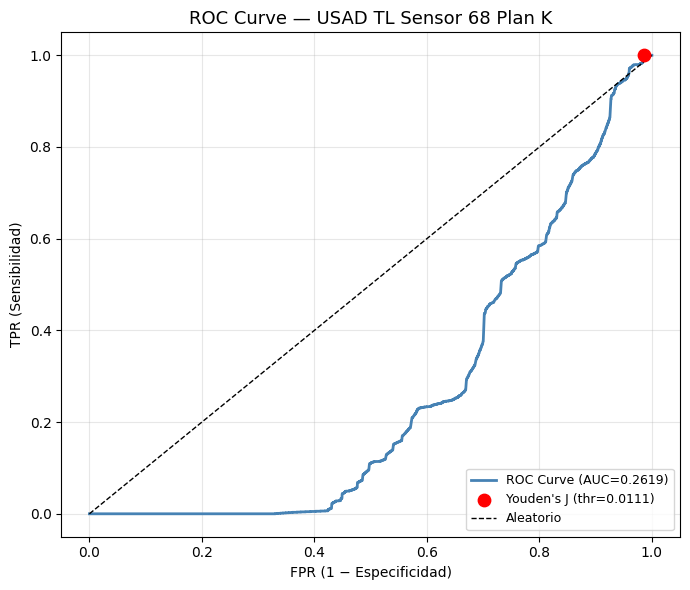

In [16]:
# Celda 14 — Gráfica 3: Curva ROC + umbral Youden's J

fpr, tpr, thr_roc = roc_curve(L_val, scores_val)
auc_val = roc_auc_score(L_val, scores_val)

# Umbral Youden's J: maximiza TPR - FPR
j_scores = tpr - fpr
j_idx    = int(np.argmax(j_scores))
thr_youden = float(thr_roc[j_idx]) if j_idx < len(thr_roc) else float(thr_roc[-1])

print(f"Umbral óptimo (Youden's J): {thr_youden:.6f} | TPR={tpr[j_idx]:.4f}  FPR={fpr[j_idx]:.4f}  AUC={auc_val:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC={auc_val:.4f})')
ax.scatter(fpr[j_idx], tpr[j_idx], color='red', s=80, zorder=5,
           label=f"Youden's J (thr={thr_youden:.4f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio')
ax.set_xlabel('FPR (1 − Especificidad)')
ax.set_ylabel('TPR (Sensibilidad)')
ax.set_title(f'ROC Curve — USAD TL Sensor {cfg.sensor_id} Plan K', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafica_03_roc.png', dpi=150, bbox_inches='tight')
plt.show()

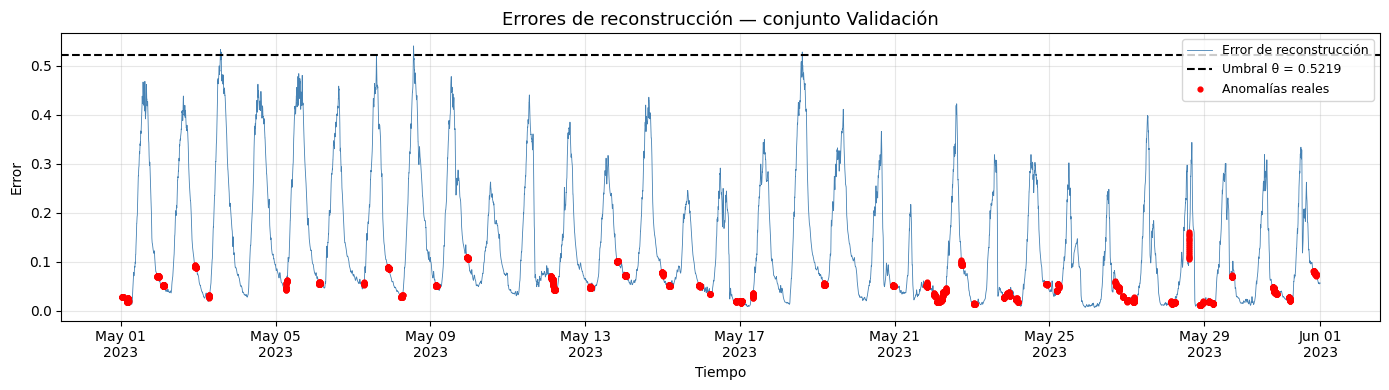

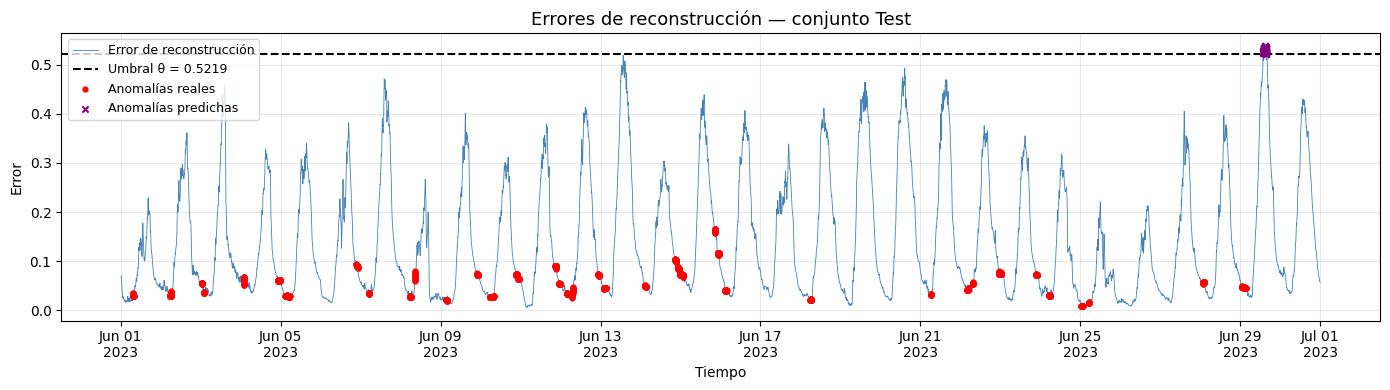

In [17]:
# Celda 15 — Gráficas 4 y 5: Error de reconstrucción (Plotly interactivo)

def plot_error_reconstruction_plotly(df_w, threshold, label, show_pred=False, save_html=None):
    dates = pd.to_datetime(df_w['fecha'])

    fig = go.Figure()

    # Línea de error de reconstrucción
    fig.add_trace(go.Scatter(
        x=dates,
        y=df_w['error'],
        mode='lines',
        name='Error de reconstrucción',
        line=dict(color='steelblue', width=0.8),
        hovertemplate='%{x|%Y-%m-%d %H:%M}<br>Error: %{y:.6f}<extra></extra>'
    ))

    # Umbral (línea horizontal)
    fig.add_hline(
        y=threshold,
        line_dash='dash', line_color='black', line_width=1.5,
        annotation_text=f'θ = {threshold:.4f}',
        annotation_font_size=11,
        annotation_position='top left'
    )

    # Anomalías reales
    anom_real = df_w[df_w['flag'] == 1]
    fig.add_trace(go.Scatter(
        x=pd.to_datetime(anom_real['fecha']),
        y=anom_real['error'],
        mode='markers',
        name='Anomalías reales',
        marker=dict(color='red', size=7, symbol='circle',
                    line=dict(color='darkred', width=0.5)),
        hovertemplate='%{x|%Y-%m-%d %H:%M}<br>Error: %{y:.6f}<br><b>ANOMALÍA REAL</b><extra></extra>'
    ))

    # Anomalías predichas (solo Test)
    if show_pred:
        anom_pred = df_w[df_w['error'] >= threshold]
        fig.add_trace(go.Scatter(
            x=pd.to_datetime(anom_pred['fecha']),
            y=anom_pred['error'],
            mode='markers',
            name='Anomalías predichas',
            marker=dict(color='purple', size=10, symbol='x',
                        line=dict(color='purple', width=2)),
            hovertemplate='%{x|%Y-%m-%d %H:%M}<br>Error: %{y:.6f}<br><b>PREDICHA</b><extra></extra>'
        ))

    fig.update_layout(
        title=dict(
            text=f'Errores de reconstrucción — conjunto {label}  (v2: α={cfg.alpha}, β={cfg.beta})',
            font=dict(size=14)
        ),
        xaxis=dict(
            title='Tiempo',
            rangeslider=dict(visible=True, thickness=0.06),
            type='date'
        ),
        yaxis_title='Score de anomalía',
        hovermode='closest',
        template='plotly_white',
        height=460,
        legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.85)')
    )

    fig.show()
    if save_html:
        fig.write_html(save_html)
        print(f'Guardado: {save_html}')


plot_error_reconstruction_plotly(
    df_val_w, umbral, 'Validación', show_pred=False,
    save_html='grafica_04_error_val.html'
)
plot_error_reconstruction_plotly(
    df_test_w, umbral, 'Test', show_pred=True,
    save_html='grafica_05_error_test.html'
)


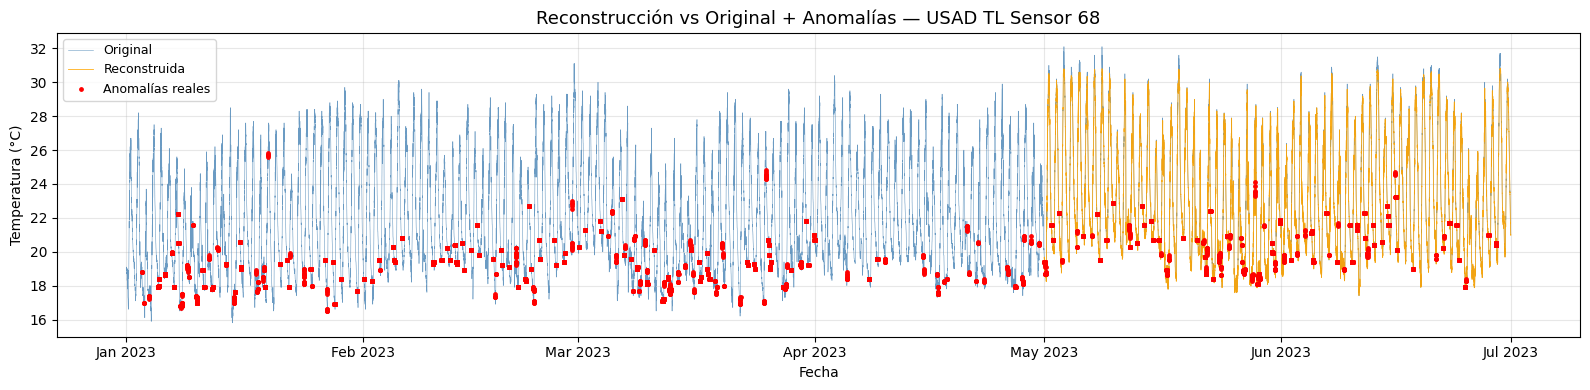

In [18]:
# Celda 16 — Gráfica 6: Reconstrucción vs Original (período completo)

fig, ax = plt.subplots(figsize=(16, 4))

# Señal original completa
ax.plot(df['fecha_hora'], df['t_clip'],
        color='steelblue', lw=0.4, alpha=0.8, label='Original')

# Reconstrucción en val y test
ax.plot(pd.to_datetime(df_val_w['fecha']),  df_val_w['t_recon'],
        color='orange', lw=0.6, alpha=0.9, label='Reconstruida')
ax.plot(pd.to_datetime(df_test_w['fecha']), df_test_w['t_recon'],
        color='orange', lw=0.6, alpha=0.9)

# Anomalías reales
anom_all = df[df['calidad_dudosa']]
ax.scatter(anom_all['fecha_hora'], anom_all['t_clip'],
           color='red', s=6, zorder=5, label='Anomalías reales')

ax.set_title(
    f'Reconstrucción vs Original + Anomalías — USAD TL Sensor {cfg.sensor_id}',
    fontsize=13
)
ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafica_06_recon_completa.png', dpi=150, bbox_inches='tight')
plt.show()

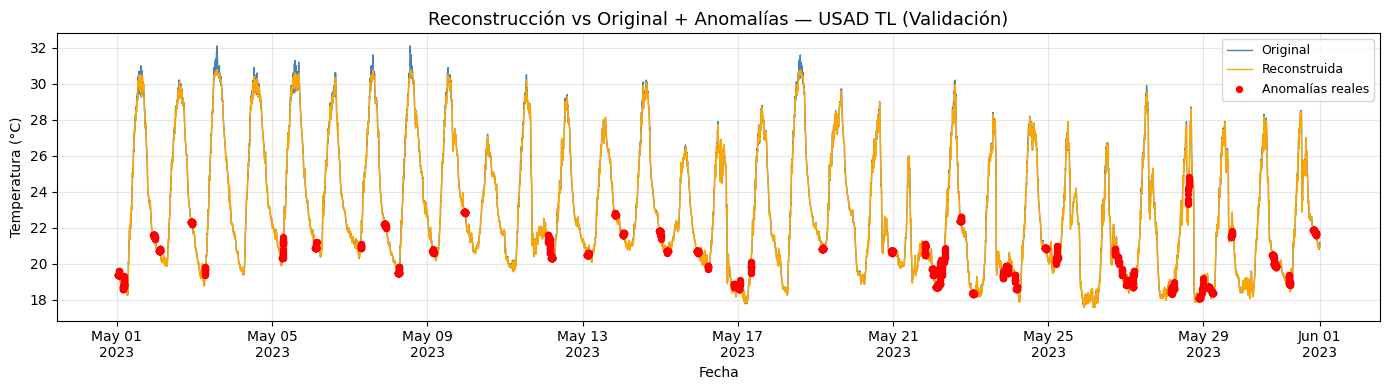

In [19]:
# Celda 17 — Gráfica 7: Reconstrucción vs Original — zoom Validación

fig, ax = plt.subplots(figsize=(14, 4))

dates_v = pd.to_datetime(df_val_w['fecha'])
ax.plot(dates_v, df_val_w['t_orig'],  color='steelblue', lw=1.0, label='Original')
ax.plot(dates_v, df_val_w['t_recon'], color='orange',    lw=1.0, label='Reconstruida')

anom_val_plot = df_val_w[df_val_w['flag'] == 1]
ax.scatter(pd.to_datetime(anom_val_plot['fecha']), anom_val_plot['t_orig'],
           color='red', s=18, zorder=5, label='Anomalías reales')

ax.set_title(
    f'Reconstrucción vs Original + Anomalías — USAD TL (Validación)',
    fontsize=13
)
ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%Y'))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafica_07_recon_val.png', dpi=150, bbox_inches='tight')
plt.show()

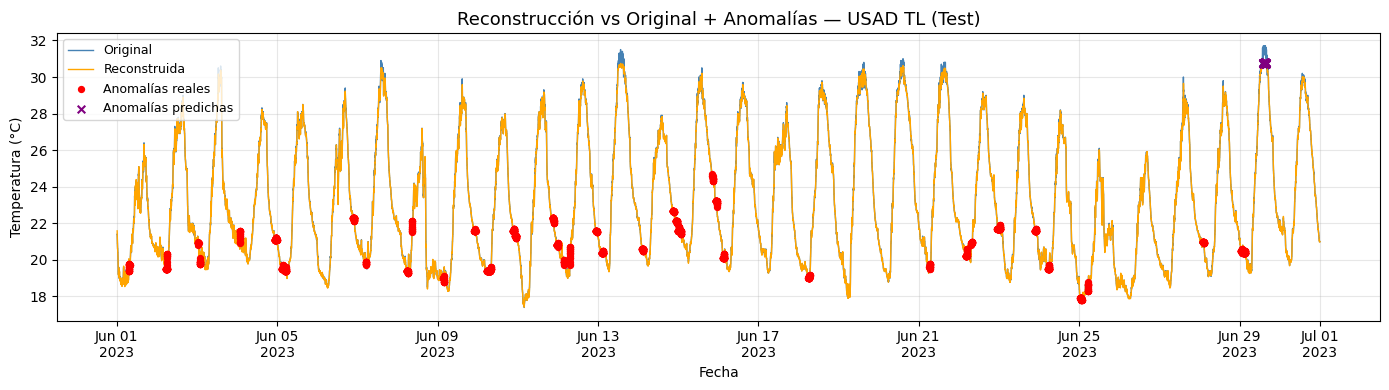

In [20]:
# Celda 18 — Gráfica 8: Reconstrucción vs Original — zoom Test + predicciones

df_test_w['flag_pred'] = (df_test_w['error'] >= umbral).astype(int)

fig, ax = plt.subplots(figsize=(14, 4))

dates_t = pd.to_datetime(df_test_w['fecha'])
ax.plot(dates_t, df_test_w['t_orig'],  color='steelblue', lw=1.0, label='Original')
ax.plot(dates_t, df_test_w['t_recon'], color='orange',    lw=1.0, label='Reconstruida')

anom_real_t = df_test_w[df_test_w['flag'] == 1]
anom_pred_t = df_test_w[df_test_w['flag_pred'] == 1]

ax.scatter(pd.to_datetime(anom_real_t['fecha']), anom_real_t['t_orig'],
           color='red', s=18, zorder=5, label='Anomalías reales')
ax.scatter(pd.to_datetime(anom_pred_t['fecha']), anom_pred_t['t_recon'],
           color='purple', marker='x', s=30, zorder=6, label='Anomalías predichas')

ax.set_title(
    f'Reconstrucción vs Original + Anomalías — USAD TL (Test)',
    fontsize=13
)
ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%Y'))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafica_08_recon_test.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Celda 19 — Gráfica 9: Métricas de clasificación (Val y Test)

def compute_and_print_metrics(y_true, y_scores, threshold, label):
    y_pred = (y_scores >= threshold).astype(int)
    cm     = sk_confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    acc  = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    print(f"=== Métricas — Conjunto de {label} ===")
    print(f"  Accuracy:      {acc:.4f}")
    print(f"  Balanced Acc:  {bacc:.4f}")
    print(f"  Precision:     {prec:.4f}")
    print(f"  Recall:        {rec:.4f}")
    print(f"  F1:            {f1:.4f}")
    print()
    print(f"  Confusion Matrix:")
    print(f"  {'':20s} Real Normal   Real Anomalía")
    print(f"  {'Pred Normal':20s} {tn:>12,}  {fn:>13,}")
    print(f"  {'Pred Anomalía':20s} {fp:>12,}  {tp:>13,}")
    print()
    return {'acc': acc, 'bacc': bacc, 'prec': prec, 'rec': rec,
            'f1': f1, 'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn}


df_val_w['flag_pred']  = (df_val_w['error']  >= umbral).astype(int)

metrics_val  = compute_and_print_metrics(L_val,   scores_val,  umbral, 'Validación')
metrics_test = compute_and_print_metrics(L_test,  scores_test, umbral, 'Test')

# Tabla resumen
summary = pd.DataFrame(
    [metrics_val, metrics_test],
    index=['Validación', 'Test']
)[['acc', 'bacc', 'prec', 'rec', 'f1', 'TP', 'TN', 'FP', 'FN']]
summary.columns = ['Accuracy', 'Balanced Acc', 'Precision', 'Recall', 'F1',
                   'TP', 'TN', 'FP', 'FN']
print("=== Resumen ===")
print(summary.to_string(float_format='{:.4f}'.format))

=== Métricas — Conjunto de Validación ===
  Accuracy:      0.9505
  Balanced Acc:  0.4995
  Precision:     0.0000
  Recall:        0.0000
  F1:            0.0000

  Confusion Matrix:
                       Real Normal   Real Anomalía
  Pred Normal                42,395          2,165
  Pred Anomalía                  45              0

=== Métricas — Conjunto de Test ===
  Accuracy:      0.9554
  Balanced Acc:  0.4988
  Precision:     0.0000
  Recall:        0.0000
  F1:            0.0000

  Confusion Matrix:
                       Real Normal   Real Anomalía
  Pred Normal                41,264          1,824
  Pred Anomalía                 101              0

=== Resumen ===
            Accuracy  Balanced Acc  Precision  Recall     F1  TP     TN   FP    FN
Validación    0.9505        0.4995     0.0000  0.0000 0.0000   0  42395   45  2165
Test          0.9554        0.4988     0.0000  0.0000 0.0000   0  41264  101  1824


In [22]:
# Celda 20 — Guardar modelo fine-tuneado (Plan K v2)

torch.save(
    {
        'model_state_dict': model.state_dict(),
        'scaler_min':       scaler.data_min_[0],
        'scaler_max':       scaler.data_max_[0],
        'threshold':        umbral,
        'threshold_f1':     umbral_f1,
        'score_inverted':   score_inverted,
        'top_cols':         top_cols.tolist(),
        'alpha':            cfg.alpha,
        'beta':             cfg.beta,
        'config':           cfg.__dict__,
        'metrics_val':      metrics_val,
        'metrics_test':     metrics_test,
    },
    'modelos/usad/model_tl_sensor68_planK_v2.pth'
)
print('Modelo guardado: modelos/usad/model_tl_sensor68_planK_v2.pth')
print(f'Umbral (BA):       {umbral:.6f}')
print(f'Umbral (F1):       {umbral_f1:.6f}')
print(f'Score invertido:   {score_inverted}')
print(f'alpha={cfg.alpha}  beta={cfg.beta}')
print(f'Balanced Acc Val:  {metrics_val["bacc"]:.4f}')
print(f'Balanced Acc Test: {metrics_test["bacc"]:.4f}')


Modelo guardado: modelos/usad/model_tl_sensor68_planK.pth
Umbral: 0.521907
Balanced Accuracy (Val):  0.4995
Balanced Accuracy (Test): 0.4988
